In [1]:
# Imports Libraries
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, correlate
from scipy.stats import pearsonr, linregress

In [48]:
# Read everything in the data file into lines
# lines is a list, each element is one line in the data file
def readLDFdata(filepath):
    file_path = filepath
    file = open("data/" + file_path + ".txt", "r")
    lines = file.readlines()


    # Finds where the raw data starts
    # Skips the two blank lines at very beginning
    i = 0
    while lines[i] != "4) Trace Data\n":
        i += 1
    i += 2


    # Read All Raw LDF Data
    raw_data_ldf = []
    for j in range(i, len(lines)):
        line = lines[j]
        ldf_val = float(line.split("\t")[4])
        raw_data_ldf.append(ldf_val)

    # See if the last datapoint is correct
    return raw_data_ldf
# Read everything in the data file into lines
def readAMIdata(filepath):
    file_path = filepath
    file = open("data/" + file_path + ".csv", "r")
    lines = file.readlines()

    # Finds where the raw data starts
    # Skips the one blank line at very beginning
    i = 0
    while lines[i] != "No,Time (hr:min:sec),LeftLU,Event messages\n":
        i += 1
    i += 1

    # Read how many lines we need to read in AMI
    numDataLines = int(lines[13].split(",")[1])

    raw_data_ami = []
    for j in range(i, i + numDataLines):
        line = lines[j]
        ami_val = float(line.split(",")[2])
        raw_data_ami.append(ami_val)

    # See if the last datapoint is correct
    return raw_data_ami

In [3]:
def combine_datasets(time_dict, sensor_data):
    """
    Combine time interval dictionary with sensor data.
    
    Parameters:
    - time_dict: dict with person names as keys, and condition: {start, end} as values
    - sensor_data: list of lists, each sublist corresponds to a person in same order as time_dict.keys()
    
    Returns:
    - Combined dict with same structure but sensor slices instead of time intervals
    """
    people = list(time_dict.keys())
    result = {}
    
    for person_idx, person_name in enumerate(people):
        person_intervals = time_dict[person_name]
        result[person_name] = {}
        
        for condition, interval in person_intervals.items():
            if interval is None:
                result[person_name][condition] = []
            else:
                start = interval['start']
                end = interval['end']
                # Slice the sensor data for this person
                result[person_name][condition] = sensor_data[person_idx][start:end]
    
    return result


In [56]:
people = ["Manli"]
LDF_data = []
for i in people:
    LDF_data.append(readLDFdata(i+" pulley"))
AMI_data = []
for i in people:
    AMI_data.append(readAMIdata(i+" pulley"))

In [57]:
with open('data/times.json', 'r', encoding='utf-8') as file:
    times = json.load(file)


In [58]:
LDF_formatted_data = combine_datasets(times, LDF_data)
AMI_formatted_data = combine_datasets(times, AMI_data)

In [59]:
def extract_peak_heights(signal, distance=5, prominence=20):
    """
    Return peak heights computed as peak value minus the most recent valley value.
    """
    signal = np.asarray(signal)

    if signal.size == 0:
        return []

    peaks_idx, _ = find_peaks(signal, distance=distance, prominence=prominence)
    valleys_idx, _ = find_peaks(-signal, distance=distance, prominence=prominence)

    peak_heights = []
    for peak_idx in peaks_idx:
        prior_valleys = valleys_idx[valleys_idx < peak_idx]
        if prior_valleys.size == 0:
            continue

        valley_idx = prior_valleys[-1]
        peak_heights.append(float(signal[peak_idx] - signal[valley_idx]))

    return peak_heights

def build_peak_height_dataset(formatted_data, distance=5, prominence=20):
    """
    Keep the same person/condition structure, but replace each signal with peak heights.
    """
    peak_height_data = {}

    for person, conditions in formatted_data.items():
        peak_height_data[person] = {}
        for condition, signal in conditions.items():
            peak_height_data[person][condition] = extract_peak_heights(
                signal,
                distance=distance,
                prominence=prominence
            )

    return peak_height_data

LDF_peak_height_data = build_peak_height_dataset(LDF_formatted_data, distance=12, prominence=50)
AMI_peak_height_data = build_peak_height_dataset(AMI_formatted_data, distance=12, prominence=50)


In [63]:
conditions = ['No weight', '2.5-lbs', '5.0-lbs', '7.5-lbs', '10-lbs']
condition_colors = {
    'No weight': '#4C78A8',
    '2.5-lbs': '#F58518',
    '5.0-lbs': '#54A24B',
    '7.5-lbs': '#E45756',
    '10-lbs': '#B279A2'
}

def remove_outliers_iqr(values, multiplier=1.5):
    """
    Return a boolean mask that keeps values inside the IQR bounds.
    """
    values = np.asarray(values, dtype=float)

    if values.size < 4:
        return np.ones(values.size, dtype=bool)

    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    iqr = q3 - q1

    if iqr == 0:
        return np.ones(values.size, dtype=bool)

    lower_bound = q1 - multiplier * iqr
    upper_bound = q3 + multiplier * iqr
    return (values >= lower_bound) & (values <= upper_bound)

def extract_peak_points(signal, distance=5, prominence=20, window_seconds=450):
    """
    Return peak times and peak heights (peak - previous valley) within the first window.
    """
    signal = np.asarray(signal[:window_seconds])

    if signal.size == 0:
        return [], []

    peaks_idx, _ = find_peaks(signal, distance=distance, prominence=prominence)
    valleys_idx, _ = find_peaks(-signal, distance=distance, prominence=prominence)

    peak_times = []
    peak_heights = []
    for peak_idx in peaks_idx:
        prior_valleys = valleys_idx[valleys_idx < peak_idx]
        if prior_valleys.size == 0:
            continue

        valley_idx = prior_valleys[-1]
        peak_times.append(float(peak_idx))
        peak_heights.append(float(signal[peak_idx] - signal[valley_idx]))

    return peak_times, peak_heights

def collect_condition_peak_points(formatted_data, distance=5, prominence=20, window_seconds=450):
    """
    Pool peak points across all people, using consecutive 450 s condition windows.
    """
    pooled_points = {condition: {'times': [], 'heights': []} for condition in conditions}

    for condition_idx, condition in enumerate(conditions):
        condition_offset = condition_idx * window_seconds

        for person, person_data in formatted_data.items():
            signal = person_data.get(condition, [])
            peak_times, peak_heights = extract_peak_points(
                signal,
                distance=distance,
                prominence=prominence,
                window_seconds=window_seconds
            )

            pooled_points[condition]['times'].extend([
                condition_offset + peak_time for peak_time in peak_times
            ])
            pooled_points[condition]['heights'].extend(peak_heights)

    for condition in conditions:
        heights = np.asarray(pooled_points[condition]['heights'], dtype=float)
        times = np.asarray(pooled_points[condition]['times'], dtype=float)
        keep_mask = remove_outliers_iqr(heights)
        pooled_points[condition]['times'] = times[keep_mask].tolist()
        pooled_points[condition]['heights'] = heights[keep_mask].tolist()

    return pooled_points

def plot_peak_dotplot(pooled_points, signal_label):
    plt.figure(figsize=(14, 6))

    all_times = []
    all_heights = []
    for condition in conditions:
        times = pooled_points[condition]['times']
        heights = pooled_points[condition]['heights']
        all_times.extend(times)
        all_heights.extend(heights)

        plt.scatter(
            times,
            heights,
            s=32,
            alpha=0.75,
            color=condition_colors[condition],
            label=condition
        )

    if len(all_times) >= 2:
        slope, intercept, _, _, _ = linregress(all_times, all_heights)
        x_line = np.linspace(0, 450 * len(conditions), 450)
        y_line = slope * x_line + intercept
        plt.plot(x_line, y_line, color='black', linewidth=2, label='Overall trend')

    for boundary in range(450, 450 * len(conditions), 450):
        plt.axvline(boundary, color='gray', linestyle='--', linewidth=1, alpha=0.5)

    y_top = plt.ylim()[1]
    for idx, condition in enumerate(conditions):
        midpoint = idx * 450 + 150
        plt.text(midpoint, y_top, condition, ha='center', va='bottom', fontsize=10)

    plt.xlim(0, 450 * len(conditions))
    plt.ylim(0, 160)
    plt.xlabel('Time (s) across first 450 s of each condition')
    plt.ylabel('Peak height (peak - valley)')
    plt.title(f'{signal_label} Peak Heights Across Conditions')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_peak_bargraph(peak_height_data, signal_label):
    pooled_means = []
    pooled_stds = []
    x_positions = np.arange(len(conditions))

    for condition in conditions:
        pooled_values = []
        for person in peak_height_data:
            pooled_values.extend(peak_height_data[person].get(condition, []))

        pooled_values = np.asarray(pooled_values, dtype=float)
        pooled_values = pooled_values[remove_outliers_iqr(pooled_values)]
        pooled_means.append(np.mean(pooled_values) if pooled_values.size else np.nan)
        pooled_stds.append(np.std(pooled_values, ddof=1) if pooled_values.size > 1 else 0.0)

    pooled_means = np.asarray(pooled_means, dtype=float)
    pooled_stds = np.asarray(pooled_stds, dtype=float)

    plt.figure(figsize=(10, 6))
    plt.bar(
        x_positions,
        pooled_means,
        yerr=pooled_stds,
        capsize=6,
        color=[condition_colors[c] for c in conditions],
        alpha=0.8
    )

    valid_mask = ~np.isnan(pooled_means)
    if np.sum(valid_mask) >= 2:
        slope, intercept, _, _, _ = linregress(x_positions[valid_mask], pooled_means[valid_mask])
        x_line = np.linspace(x_positions[0], x_positions[-1], 200)
        y_line = slope * x_line + intercept
        plt.plot(x_line, y_line, color='black', linewidth=2, label='Trend line')
        plt.legend()

    plt.xticks(x_positions, conditions)
    plt.ylabel('Average peak height (peak - valley)')
    plt.title(f'{signal_label} Average Peak Height by Condition')
    plt.tight_layout()
    plt.show()

LDF_peak_points = collect_condition_peak_points(LDF_formatted_data, distance=5, prominence=20, window_seconds=450)
AMI_peak_points = collect_condition_peak_points(AMI_formatted_data, distance=5, prominence=50, window_seconds=450)


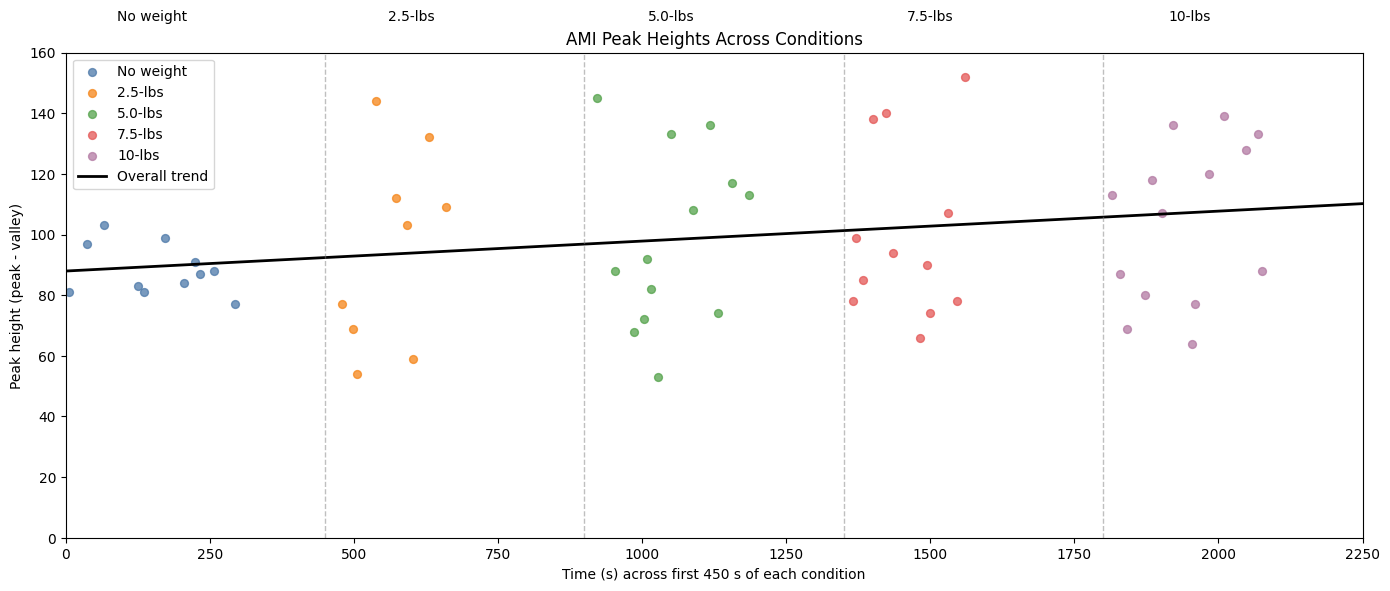

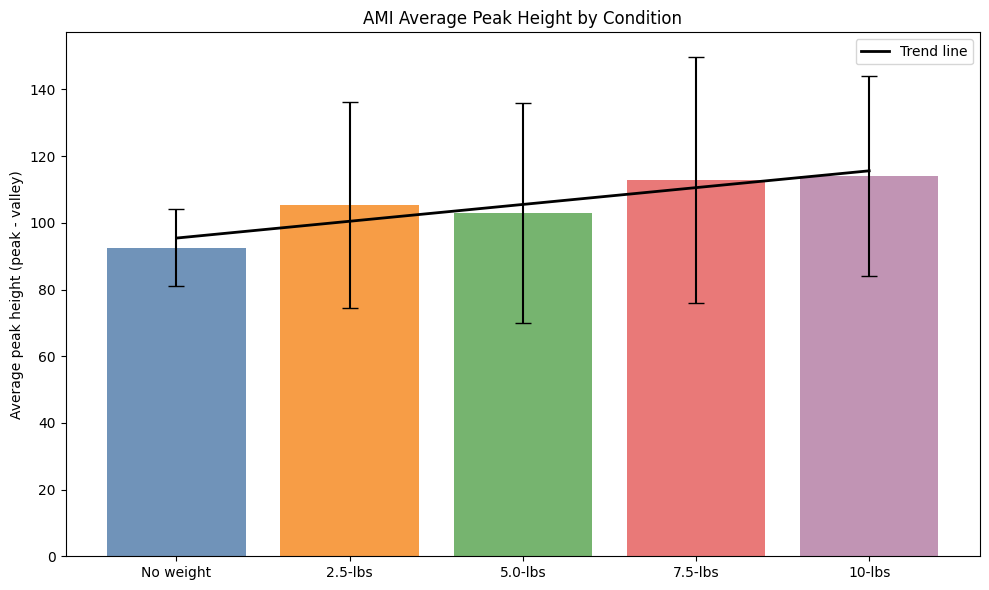

In [64]:
plot_peak_dotplot(AMI_peak_points, 'AMI')
plot_peak_bargraph(AMI_peak_height_data, 'AMI')


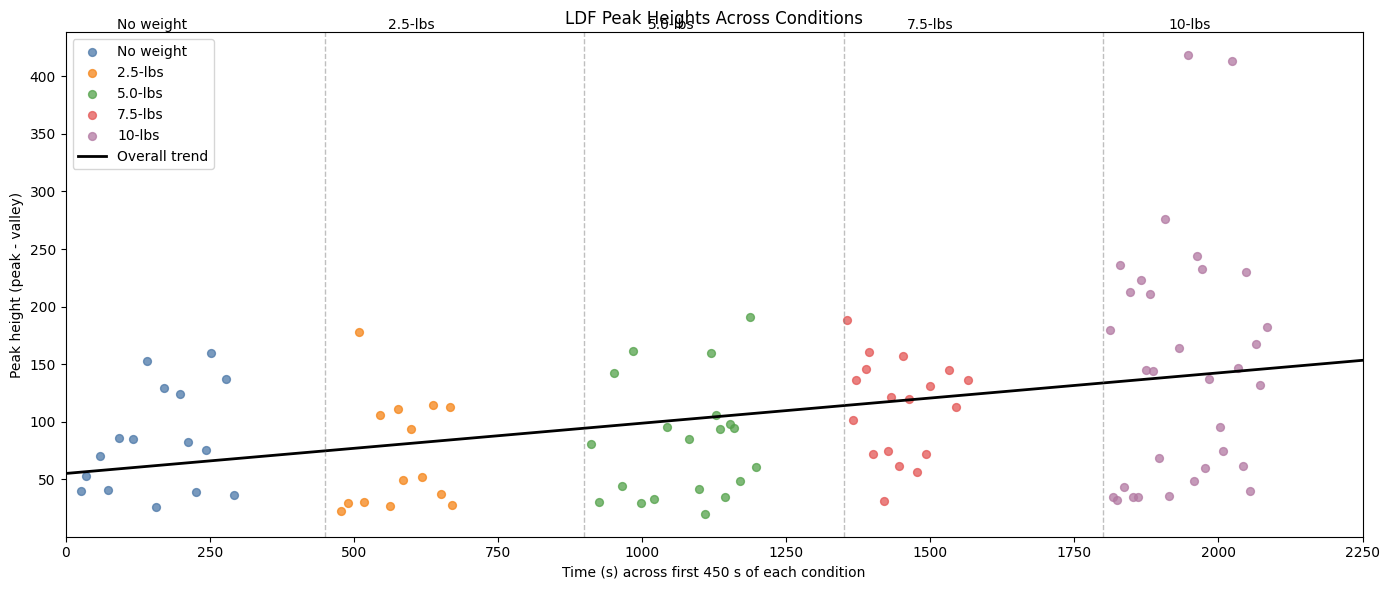

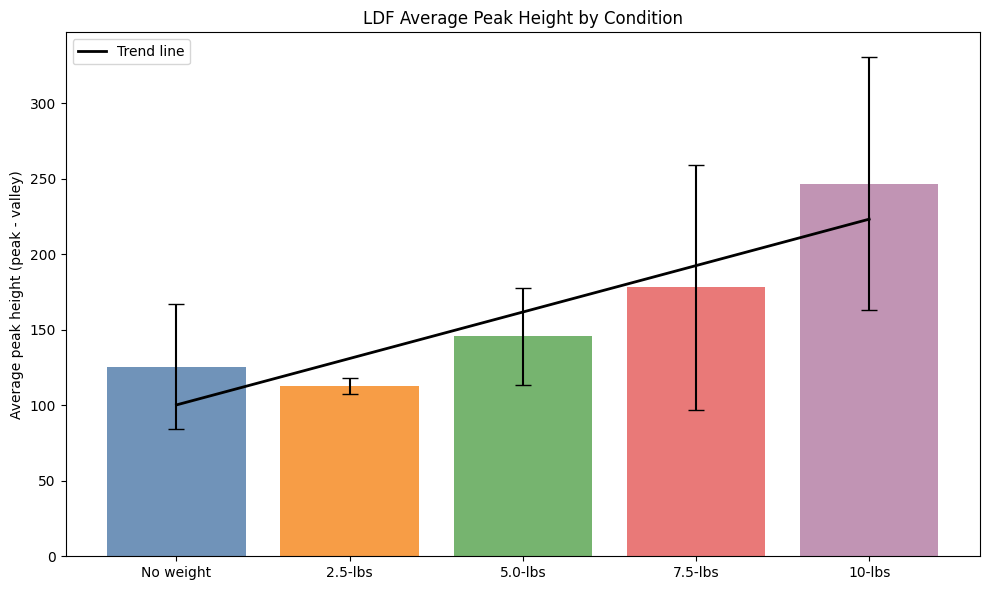

In [62]:
plot_peak_dotplot(LDF_peak_points, 'LDF')
plot_peak_bargraph(LDF_peak_height_data, 'LDF')
